# PIECEWISE PREDICTIONS

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.score import Score
from src.system_discovery import SystemDiscovery
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

# Individual models

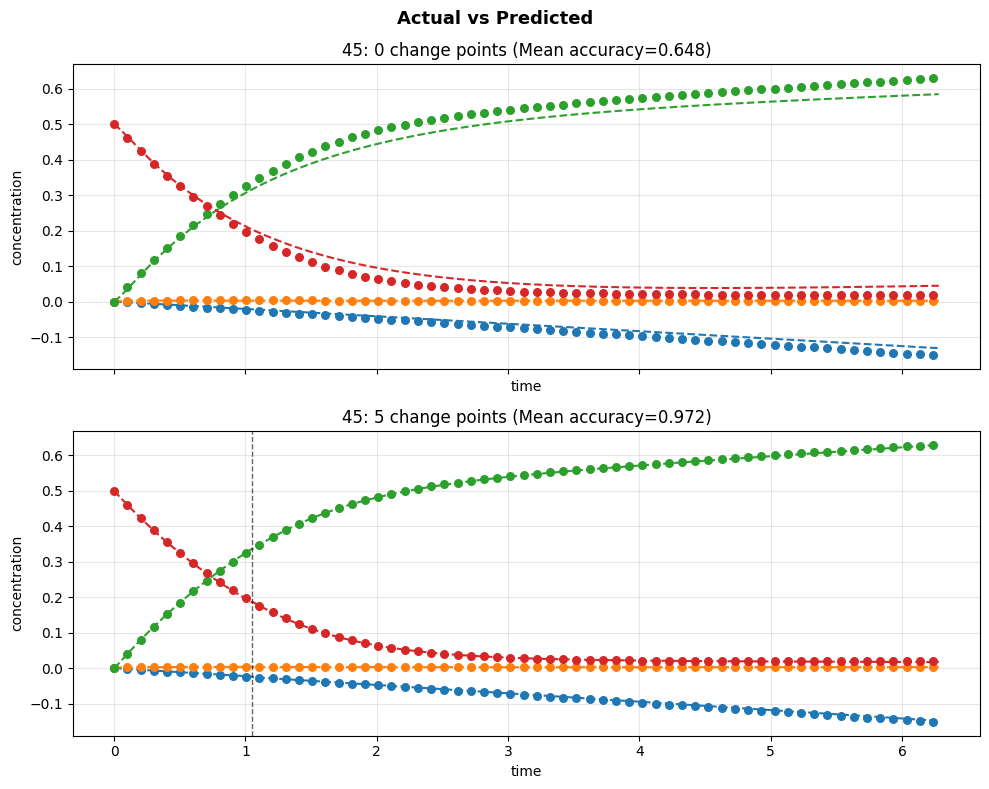

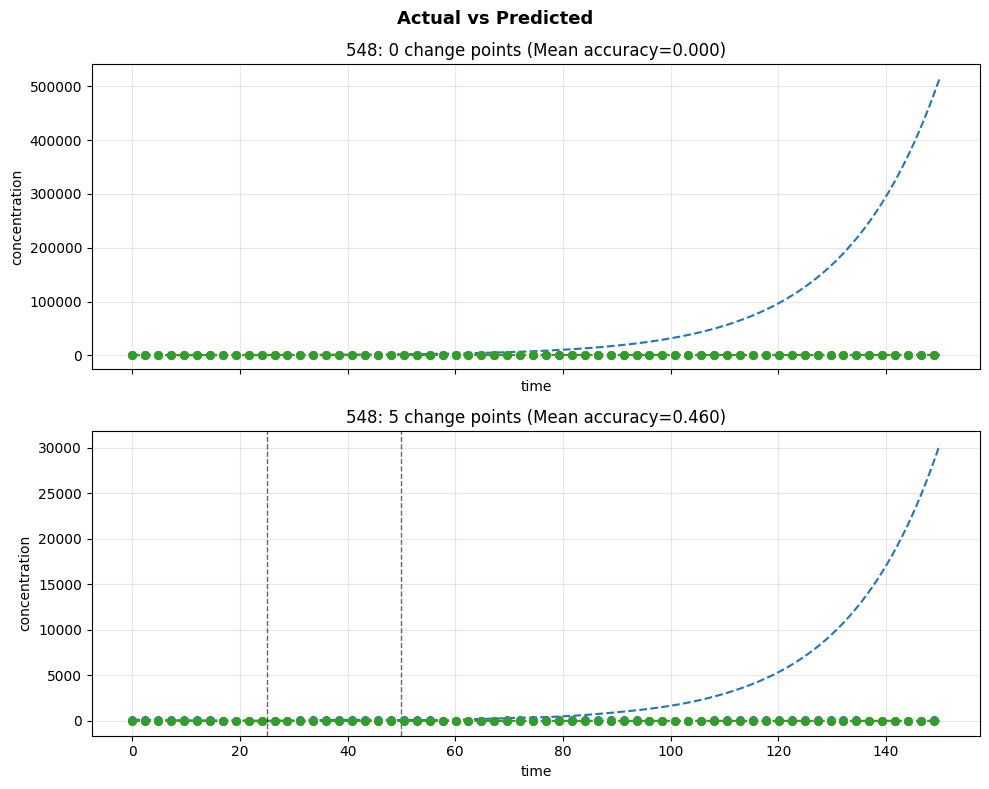

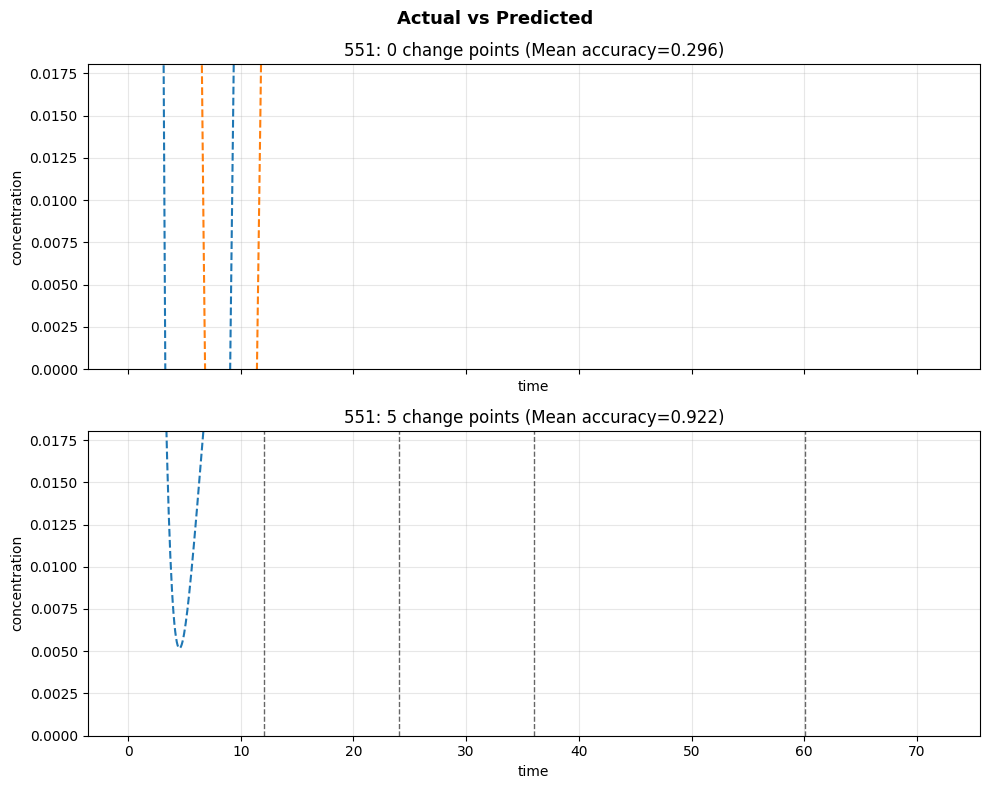

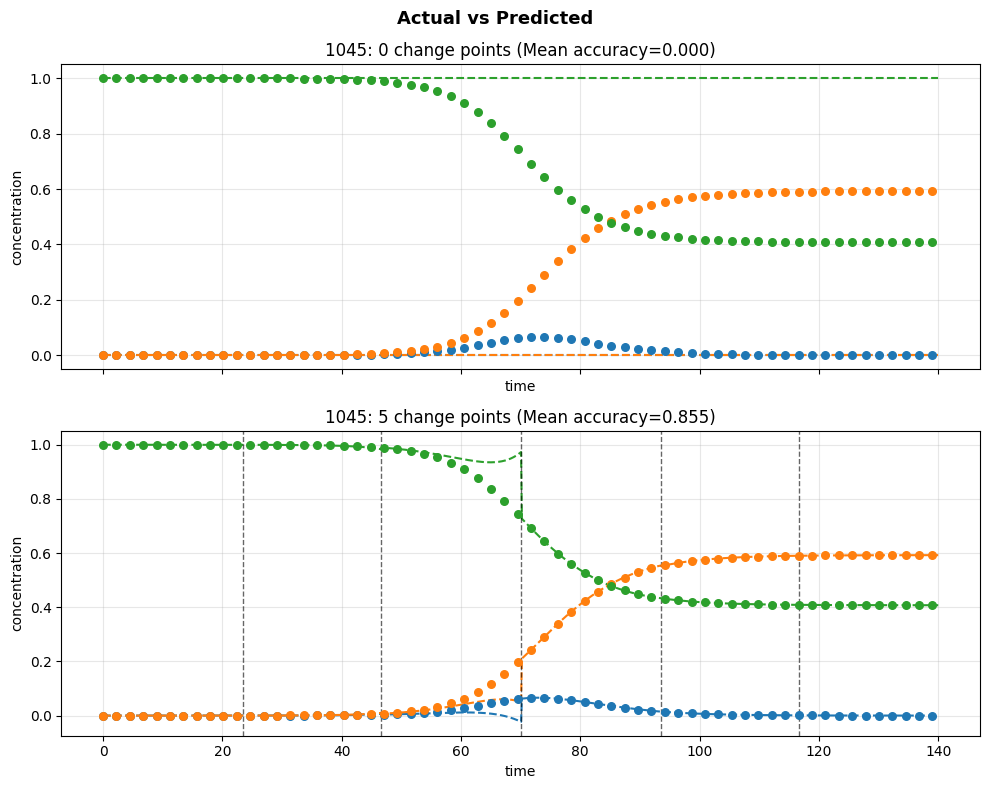

In [8]:
for model_num in [45, 548, 551, 1045]:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    try:
        psd = PiecewiseSystemDiscovery(df, max_changepoint=5, min_segment_length=30,
                                        max_fractional_reduction=0.01, model_name=str(model_num))
        psd.fit()
        result = psd.plotPiecewise(legend=False, num_true_point=60)
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

# CDFs

In [3]:
threshold = 0.01
#path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
DF = pd.read_csv(path)
DF.columns

Index(['system_id', 'aggregation_type', 'mean', 'min', 'max', 'count',
       'invalid_count', 'p05', 'p10', 'p20', 'p25', 'p30', 'p50', 'p80', 'p90',
       'p95', 'p99', 'a80', 'a90', 'a95', 'max_changepoint',
       'min_segment_length', 'max_fractional_reduction',
       'coefficient_threshold', 'num_changepoint'],
      dtype='str')

In [5]:
def getColumn(df: pd.DataFrame, col: str = "a80",  is_species: bool = True, max_changepoint: int = 10) -> pd.Series:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    return result_df[col]

# Tests
ser = getColumn(DF)
ser

22      0.620621
23      0.464000
24      0.224224
25      0.436000
26      0.467467
          ...   
9635    0.726727
9652    0.929930
9653    0.840841
9654    0.866000
9655    0.800801
Name: a80, Length: 2255, dtype: float64

In [ ]:
def plotCDF(max_changepoints=[0, 1, 5, 10, 20], num_random_trial: int = 10, is_species: bool = True):
    dct = {c: getColumn(DF, col="a80", max_changepoint = c, num_random_trial=num_random_trial, is_species=is_species) for c in max_changepoints}
    for key, value in dct.items():
        Score.plotCDFArray(value)
    ax = plt.gca()
    ax.legend([str(c) for c in max_changepoints])
    ax.set_xlabel("fraction 80% accurate")
    qualifier = "species" if is_species else "model"
    ax.set_title(f"{qualifier} CDF, num_random_trial: {num_random_trial}")

plotCDF()

In [ ]:
plotCDF(is_species = False)

In [ ]:
# threshold = 0.01
plotCDF()